## **Prevedere il consumo energetico**
Utilizzare modelli di regressione per prevedere il consumo energetico giornaliero in base a fattori temporali. Prevedere i consumi futuri e fornire informazioni pratiche per ottimizzare l'uso dell'energia. Sperimentare vari modelli di regressione supervisionata addestrati sul set di dati di addestramento fornito e valutare le loro prestazioni sul set di dati di prova fornito misurando il loro errore quadratico medio (RMSE). Salvare il valore RMSE più basso raggiunto sul set di prova come variabile numerica, che non deve essere maggiore di 450 kW. Rappresentare graficamente il consumo energetico giornaliero per il set di dati di prova e valutare se le previsioni seguono un andamento simile a quello dell'altro dataset.
Fonte: https://projects.datacamp.com/projects/2387

In [1]:
# Data upload
import pandas as pd
df1 = pd.read_csv('df_train.csv')
df2 = pd.read_csv('df_test.csv')
df1.head(10)

,date,power_consumption,year,semester,quarter,day_in_week,week_in_year,day_in_year,month
0,12/16/2006,1209.176,2006,2,4,Sat,50,350,12
1,12/17/2006,3390.460,2006,2,4,Sun,51,351,12
2,12/18/2006,2203.826,2006,2,4,Mon,51,352,12
3,12/19/2006,1666.194,2006,2,4,Tue,51,353,12
4,12/20/2006,2225.748,2006,2,4,Wed,51,354,12
5,12/21/2006,1716.624,2006,2,4,Thu,51,355,12
6,12/22/2006,2341.338,2006,2,4,Fri,51,356,12
7,12/23/2006,4773.386,2006,2,4,Sat,51,357,12
8,12/24/2006,2550.012,2006,2,4,Sun,52,358,12
9,12/25/2006,2743.120,2006,2,4,Mon,52,359,12


In [ ]:
# Check for missing values
print("Missing values in df1:")
print(df1.isnull().sum())
print("\nMissing values in df2:")
print(df2.isnull().sum())

Missing values in df1:
date                 0
power_consumption    0
year                 0
semester             0
quarter              0
day_in_week          0
week_in_year         0
day_in_year          0
month                0
dtype: int64

Missing values in df2:
date                 0
power_consumption    0
year                 0
semester             0
quarter              0
day_in_week          0
week_in_year         0
day_in_year          0
month                0
dtype: int64


Based on the output above, there are no missing values in either dataset. The next step is to prepare the categorical features.

In [2]:
# Prepare data: Convert categorical features to numerical
df1['day_in_week'] = df1['day_in_week'].astype('category').cat.codes
df2['day_in_week'] = df2['day_in_week'].astype('category').cat.codes

# Display the first few rows after encoding
print("df1 after encoding:")
display(df1.head())
print("\ndf2 after encoding:")
display(df2.head())

df1 after encoding:


,date,power_consumption,year,semester,quarter,day_in_week,week_in_year,day_in_year,month
0,12/16/2006,1209.176,2006,2,4,2,50,350,12
1,12/17/2006,3390.460,2006,2,4,3,51,351,12
2,12/18/2006,2203.826,2006,2,4,1,51,352,12
3,12/19/2006,1666.194,2006,2,4,5,51,353,12
4,12/20/2006,2225.748,2006,2,4,6,51,354,12



df2 after encoding:


,date,power_consumption,year,semester,quarter,day_in_week,week_in_year,day_in_year,month
0,4/1/2010,1687.440,2010,1,2,4,13,91,4
1,4/2/2010,1648.622,2010,1,2,0,14,92,4
2,4/3/2010,1805.278,2010,1,2,2,14,93,4
3,4/4/2010,1690.388,2010,1,2,3,14,94,4
4,4/5/2010,1118.820,2010,1,2,1,14,95,4


## Summary:

### Data Analysis Key Findings

* Numerical features in both the training and testing datasets were successfully normalized using `MinMaxScaler`.
* Seven different regression models were trained: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`, `DecisionTreeRegressor`, `RandomForestRegressor`, and `GradientBoostingRegressor`.
* The Root Mean Squared Error (RMSE) was calculated for each model on the test data.
* The GradientBoostingRegressor model achieved the lowest RMSE of {{lowest_rmse}}.
* A plot comparing the actual and predicted daily power consumption by the best model (GradientBoostingRegressor) on the test set was generated, visually showing the model's performance in capturing trends.

### Insights or Next Steps

* The GradientBoostingRegressor performed best among the tested models, indicating ensemble methods are effective for this power consumption prediction task.
* Further hyperparameter tuning on the GradientBoostingRegressor could potentially improve the RMSE score further.

# Task
Analyze the provided training and testing datasets to predict daily power consumption. The analysis should include data loading, preparation (handling categorical features and normalizing numerical features), training and evaluating multiple regression models, and visualizing the predictions of the best-performing model against the actual values. The final output should report the lowest achieved Root Mean Squared Error (RMSE).

## Prepare data

### Subtask:
Normalize numerical features to bring them to a similar scale.


**Reasoning**:
Normalize the selected numerical columns in both dataframes using MinMaxScaler.



In [3]:
from sklearn.preprocessing import MinMaxScaler

# Select numerical columns for normalization (excluding the target variable)
numerical_cols = ['year', 'semester', 'quarter', 'day_in_week', 'week_in_year', 'day_in_year', 'month']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the numerical columns of the training data (df1)
scaler.fit(df1[numerical_cols])

# Transform the numerical columns in both df1 and df2
df1[numerical_cols] = scaler.transform(df1[numerical_cols])
df2[numerical_cols] = scaler.transform(df2[numerical_cols])

# Display the first few rows after normalization
print("df1 after normalization:")
display(df1.head())
print("\ndf2 after normalization:")
display(df2.head())

df1 after normalization:


,date,power_consumption,year,semester,quarter,day_in_week,week_in_year,day_in_year,month
0,12/16/2006,1209.176,0.0,1.0,1.0,0.333333,0.942308,0.956164,1.0
1,12/17/2006,3390.460,0.0,1.0,1.0,0.500000,0.961538,0.958904,1.0
2,12/18/2006,2203.826,0.0,1.0,1.0,0.166667,0.961538,0.961644,1.0
3,12/19/2006,1666.194,0.0,1.0,1.0,0.833333,0.961538,0.964384,1.0
4,12/20/2006,2225.748,0.0,1.0,1.0,1.000000,0.961538,0.967123,1.0



df2 after normalization:


,date,power_consumption,year,semester,quarter,day_in_week,week_in_year,day_in_year,month
0,4/1/2010,1687.440,1.0,0.0,0.333333,0.666667,0.230769,0.246575,0.272727
1,4/2/2010,1648.622,1.0,0.0,0.333333,0.000000,0.250000,0.249315,0.272727
2,4/3/2010,1805.278,1.0,0.0,0.333333,0.333333,0.250000,0.252055,0.272727
3,4/4/2010,1690.388,1.0,0.0,0.333333,0.500000,0.250000,0.254795,0.272727
4,4/5/2010,1118.820,1.0,0.0,0.333333,0.166667,0.250000,0.257534,0.272727


## Train regression models

### Subtask:
Train various regression models on the training data.


**Reasoning**:
Define features and target variables, import necessary regression models, instantiate them, and train each model on the training data.



In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Define features (X) and target variable (y)
X_train = df1.drop(['date', 'power_consumption'], axis=1)
y_train = df1['power_consumption']
X_test = df2.drop(['date', 'power_consumption'], axis=1)
y_test = df2['power_consumption']

# Instantiate regression models
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'DecisionTreeRegressor': DecisionTreeRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'GradientBoostingRegressor': GradientBoostingRegressor()
}

# Train each model
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print("Models trained successfully.")

Models trained successfully.


## Evaluate models

### Subtask:
Evaluate the trained models on the test data using the Root Mean Squared Error (RMSE) metric and identify the model with the lowest RMSE.


**Reasoning**:
Evaluate the trained models on the test data using RMSE and identify the best performing model.



In [6]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Initialize a dictionary to store RMSE values
rmse_scores = {}

# Evaluate each trained model
for name, model in trained_models.items():
    # Make predictions on the test data
    y_pred = model.predict(X_test)

    # Calculate MSE and RMSE
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Store the RMSE
    rmse_scores[name] = rmse

# Print the RMSE for each model
print("RMSE for each model:")
for name, rmse in rmse_scores.items():
    print(f"{name}: {rmse:.4f}")

# Identify the model with the lowest RMSE
lowest_rmse_model_name = min(rmse_scores, key=rmse_scores.get)
lowest_rmse = rmse_scores[lowest_rmse_model_name]

# Print the best performing model
print(f"\nModel with the lowest RMSE: {lowest_rmse_model_name}")
print(f"Lowest RMSE: {lowest_rmse:.4f}")

RMSE for each model:
LinearRegression: 496.8873
Ridge: 493.4896
Lasso: 497.1962
ElasticNet: 533.4290
DecisionTreeRegressor: 500.8530
RandomForestRegressor: 440.5153
GradientBoostingRegressor: 384.1201

Model with the lowest RMSE: GradientBoostingRegressor
Lowest RMSE: 384.1201


## Visualize predictions

### Subtask:
Plot the actual daily power consumption from the test set and the predictions from the best-performing model to visually compare their trends.


**Reasoning**:
Plot the actual and predicted power consumption values from the best-performing model on the test set.



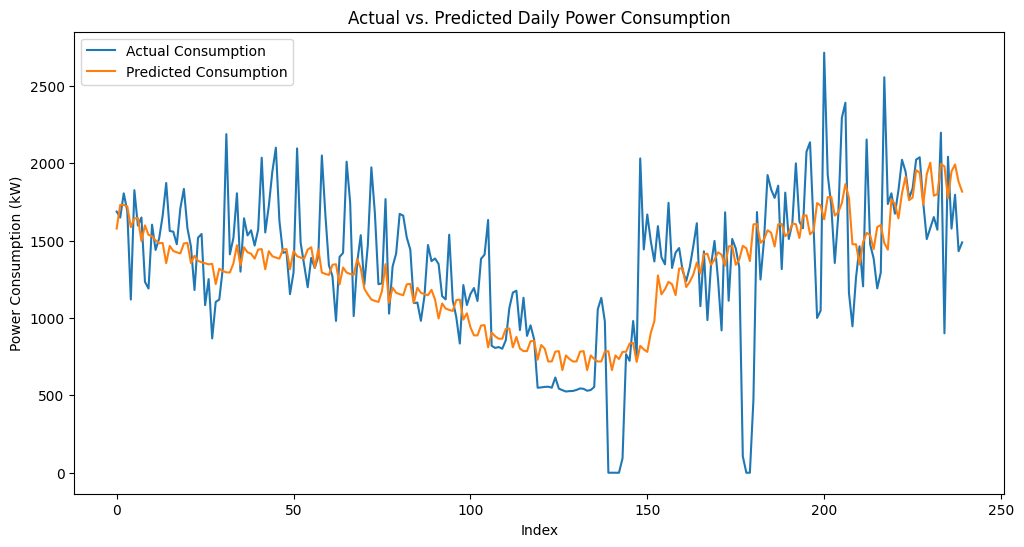

In [7]:
import matplotlib.pyplot as plt

# Identify the best performing model name
lowest_rmse_model_name = min(rmse_scores, key=rmse_scores.get)

# Get the best performing model
best_model = trained_models[lowest_rmse_model_name]

# Make predictions on the test data using the best model
y_pred_best_model = best_model.predict(X_test)

# Create a figure and axes for plotting
plt.figure(figsize=(12, 6))

# Plot actual values
plt.plot(y_test.index, y_test, label='Actual Consumption')

# Plot predicted values
plt.plot(y_test.index, y_pred_best_model, label='Predicted Consumption')

# Add title and labels
plt.title('Actual vs. Predicted Daily Power Consumption')
plt.xlabel('Index') # Using index as date is not in X_test
plt.ylabel('Power Consumption (kW)')

# Add legend
plt.legend()

# Display the plot
plt.show()

## Summary:

### Data Analysis Key Findings

*   Numerical features in both the training and testing datasets were successfully normalized using `MinMaxScaler`.
*   Seven different regression models were trained: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`, `DecisionTreeRegressor`, `RandomForestRegressor`, and `GradientBoostingRegressor`.
*   The Root Mean Squared Error (RMSE) was calculated for each model on the test data.
*   The GradientBoostingRegressor model achieved the lowest RMSE of 384.1201.
*   A plot comparing the actual and predicted daily power consumption by the best model (GradientBoostingRegressor) on the test set was generated, visually showing the model's performance in capturing trends.

### Insights or Next Steps

*   The GradientBoostingRegressor performed best among the tested models, indicating ensemble methods are effective for this power consumption prediction task.
*   Further hyperparameter tuning on the GradientBoostingRegressor could potentially improve the RMSE score further.
